In [1]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

## **Hasil Konvergensi untuk Masalah Nilai Awal**

Konvergensi untuk IVP (*Initial Value Problems* / Masalah Nilai Awal) sedikit berbeda dengan BVP(*Boundary Value Problems* / Masalah Nilai Batas). Secara umum, kita menginginkan:
$$
N \Delta t = t_f
$$
Maka:
$$
\Delta t = \frac{t_f}{N}
$$
Ambil limit:
$$
\Delta t \to 0 \;\Rightarrow\; N \to \infty
$$
Sehingga:
$$
U^N \to u(t_f)
$$

$$    \lim_{\Delta t \rightarrow 0} U^N = u(t_f)$$

di mana $t_f$ adalah waktu akhir yang diinginkan dan $N$ adalah jumlah langkah waktu yang diperlukan untuk mencapai $t_f$, sedemikian sehingga:

$$    N \Delta t = t_f \quad \Rightarrow N = \frac{t_f}{\Delta t}.$$



Namun, pada titik ini kita perlu berhati-hati ketika berbicara tentang metode yang konvergen. Sebuah metode bisa saja konvergen untuk satu set persamaan dan kondisi awal tertentu, tetapi tidak untuk yang lainnya. Secara praktis, kita menginginkan hasil konvergensi yang berlaku untuk kumpulan persamaan dan kondisi awal yang cukup luas. Dengan pertimbangan tersebut, kita memiliki definisi konvergensi untuk IVP sebagai berikut.

Jika kita menerapkan metode $r$-langkah ($r$-step method) pada sebuah ODE (Persamaan Diferensial Biasa) dalam bentuk:$$    u'(t) = f(t,u)$$dengan $f(t,u)$ yang bersifat kontinu Lipschitz terhadap $u$, dan dengan kumpulan nilai awal apa pun yang memenuhi:
$$    \lim_{\Delta t\rightarrow 0} U^\nu(\Delta t) = u_0 \quad \text{untuk} \quad \nu = 0, 1, \ldots, r-1$$
(artinya, proses bootstrap awal untuk metode multi-langkah tersebut konsisten dengan nilai awal seiring $\Delta t \rightarrow 0$), maka metode tersebut dikatakan konvergen dalam artian:
$$    \lim_{\Delta t \rightarrow 0} U^N = u(t_f).$$

Sebagaimana yang telah kita lihat sebelumnya, agar suatu metode dapat dikatakan konvergen, metode tersebut harus:

* **Konsisten** (*consistent*) – galat pemotongan lokal (*local truncation error*) $\tau = \mathcal{O}(\Delta t^p)$ di mana $p > 0$, dan
* **Stabil-nol** (*zero-stable*) – suatu bentuk stabilitas minimal serupa yang mengimplikasikan bahwa jumlah total galat saat $\Delta t \rightarrow 0$ adalah terbatas dan memiliki orde yang sama dengan $\tau$, yang kita ketahui akan menuju nol saat $\Delta t \rightarrow 0$.



### **Konvergensi Metode Satu-Langkah**

Pertimbangkan masalah linear sederhana berikut:

$$    \frac{\text{d}u}{\text{d}t} = \lambda u + g(t) \quad \text{dengan}\quad u(0) = u_0$$

Pindahkan:

$$
\frac{du}{dt} - \lambda u = g(t)
$$

Gunakan faktor integrasi:

$$
\mu(t) = e^{-\lambda t}
$$

Kalikan:

$$
e^{-\lambda t}\frac{du}{dt} - \lambda e^{-\lambda t}u = e^{-\lambda t} g(t)
$$

Bentuk turunan:

$$
\frac{d}{dt}\left( e^{-\lambda t} u \right) = e^{-\lambda t} g(t)
$$

Integralkan dari $t_0$ ke $t$:

$$
\int_{t_0}^{t} \frac{d}{dt}\left( e^{-\lambda t} u \right) dt
= \int_{t_0}^{t} e^{-\lambda \tau} g(\tau) d\tau
$$

Hasil:

$$
e^{-\lambda t} u(t) - e^{-\lambda t_0} u_0
= \int_{t_0}^{t} e^{-\lambda \tau} g(\tau) d\tau
$$

Kalikan $e^{\lambda t}$:

$$
u(t) = u_0 e^{\lambda (t - t_0)}
+ e^{\lambda t} \int_{t_0}^{t} e^{-\lambda \tau} g(\tau) d\tau
$$

Gabungkan eksponen:

$$
u(t) = u_0 e^{\lambda (t - t_0)}
+ \int_{t_0}^{t} e^{\lambda (t - \tau)} g(\tau) d\tau
$$

sehingga hasil akhirnya :

$$    u(t) = u_0 e^{\lambda (t - t_0)} + \int^t_{t_0} e^{\lambda (t - \tau)} g(\tau) d\tau.$$


### **Euler Eksplisit pada Masalah Linear**

Persamaan Awal
$$
\frac{du}{dt} = \lambda u
$$

Menerapkan metode Euler (Eksplisit/Maju) pada masalah ini menghasilkan:
$$\begin{aligned}
U^{n+1} &= U^n + \Delta t\lambda U^n \
&= (1 + \Delta t \lambda) U^n
\end{aligned}$$

Kita juga mengetahui bahwa galat pemotongan lokalnya (local truncation error) adalah:
$$
\tau^n = \frac{u(t_{n+1}) - u(t_n)}{\Delta t} - \lambda u(t_n)
$$

Ekspansi Taylor:
$$
u(t_{n+1}) = u(t_n) + \Delta t u'(t_n) + \frac{1}{2}\Delta t^2 u''(t_n) + \mathcal{O}(\Delta t^3)
$$

bagi dengan $\Delta t$:
$$
\frac{u(t_{n+1}) - u(t_n)}{\Delta t}
= u'(t_n) + \frac{1}{2}\Delta t u''(t_n) + \mathcal{O}(\Delta t^2)
$$

Substitusi:
$$
\tau^n =
\left(u'(t_n) + \frac{1}{2}\Delta t u''(t_n) + \mathcal{O}(\Delta t^2)\right)
- \lambda u(t_n)
$$

karena:
$$ u'(t_n) = \lambda u(t_n)$$

sehingga:
$$
\tau^n = \frac{1}{2}\Delta t u''(t_n) + \mathcal{O}(\Delta t^2)
$$

Dengan memperhatikan definisi awal $\tau^n$, kita dapat menulis ulang ekspresi untuk galat pemotongan lokal tersebut menjadi:

dari definisi 

$$
\frac{u(t_{n+1}) - u(t_n)}{\Delta t}
= \lambda u(t_n) + \tau^n
$$

kalikan $ \Delta t$:
$$
u(t_{n+1}) = u(t_n) + \Delta t \lambda u(t_n) + \Delta t \tau^n
$$

sehingga:
$$
u(t_{n+1}) = (1 + \Delta t \lambda) u(t_n) + \Delta t \tau^n
$$

yang jika dikombinasikan dengan penerapan metode Euler, akan menghasilkan ekspresi untuk galat global (*global error*):

$$\begin{aligned}
E^{n+1} = U^{n+1} - u(t^{n+1}) &= (1 + \Delta t \lambda) U^n - (1 + \Delta t \lambda) u(t_n) - \Delta t \tau^n \\
&= (1+\Delta t \lambda) E^n - \Delta t \tau^n \\
\end{aligned}$$


Mengekspansi ekspresi ini ke belakang hingga $n=0$ menghasilkan:$$    E^n = (1 + \Delta t \lambda)^n E^0 - \Delta t \sum^n_{i=1} (1 + \Delta t \lambda)^{n-i} \tau^{i - 1}.$$

Sekarang kita dapat melihat pentingnya suku 
$(1 + \Delta t \lambda)$. Kita dapat membatasi nilai suku ini dengan:
$$    |1 + \Delta t \lambda| \leq e^{\Delta t |\lambda|}$$
yang kemudian mengimplikasikan bahwa suku dalam penjumlahan dapat dibatasi oleh:$$    |1 + \Delta t \lambda|^{n - i} \leq e^{(n-i) \Delta t |\lambda|} \leq e^{n \Delta t |\lambda|} \leq e^{|\lambda| t_f}$$

Dengan menggunakan ekspresi ini ke dalam persamaan galat global, kita peroleh:

$$\begin{aligned}
    E^n &= (1 + \Delta t \lambda) E^0 - \Delta t \sum^n_{i=1} (1 + \Delta t \lambda)^{n-i} \tau^{i - 1} \\
    |E^n| &\leq e^{|\lambda| \Delta t} |E^0| - \Delta t \sum^n_{i=1} e^{|\lambda| t_f} |\tau^{i - 1}| \\
          &\leq e^{|\lambda| t_f} \left(|E^0| - \Delta t \sum^n_{i=1} |\tau^{i - 1}|\right) \\
          &\leq e^{|\lambda| t_f} \left(|E^0| - n \Delta t \max_{1 \leq i \leq n} |\tau^{i - 1}|\right)
\end{aligned}$$

Dengan kata lain, galat global dibatasi oleh galat global awal dan galat satu-langkah maksimum yang terjadi, dikalikan dengan jumlah langkah waktu yang diambil. Jika $N = \frac{t_f}{\Delta t}$ seperti sebelumnya dan dengan mempertimbangkan galat pemotongan lokal (*local truncation error*), kita dapat menyederhanakan ekspresi ini lebih lanjut menjadi:

$$    |E^n| \leq e^{|\lambda| t_f} \left[|E^0| + t_f \left(\frac{1}{2} \Delta t |u''| + \mathcal{O}(\Delta t^2)\right ) \right]$$


Jika kita mengasumsikan bahwa kita telah menggunakan kondisi awal $u_0$ yang benar, maka $E^0 \rightarrow 0$ seiring dengan $\Delta t \rightarrow 0$. Dengan demikian, kita dapat melihat bahwa metode tersebut benar-benar konvergen karena:
$$    |E^n| \leq e^{|\lambda| t_f} t_f \left(\frac{1}{2} \Delta t |u''| + \mathcal{O}(\Delta t^2)\right ) = \mathcal{O}(\Delta t).$$

### **Hubungan dengan Stabilitas untuk BVP**
Kita dapat melihat hubungan antara versi stabilitas sebelumnya dengan yang telah diuraikan di atas. Cobalah menuliskan metode Euler eksplisit (forward Euler) sebagai sebuah sistem linear.

Euler Eksplisit (Forward Euler):
$$
    A = \frac{1}{\Delta t} \begin{bmatrix}
        1 \\
        -(1 + \Delta t \lambda) & 1 \\
        & -(1 + \Delta t \lambda) & 1 \\
        & & -(1 + \Delta t \lambda) & 1 \\
        & & & \ddots & \ddots \\
        & & & & -(1 + \Delta t \lambda) & 1 \\
        & & & & & -(1 + \Delta t \lambda) & 1
    \end{bmatrix}
$$
dengan 
$$
    U = \begin{bmatrix} U^1 \\ U^2 \\ \vdots \\ U^N \end{bmatrix} ~~~~ 
    F = \begin{bmatrix} (1 / \Delta t + \lambda) U^0 + g(t_0) \\ g(t_1) \\ \vdots \\ g(t_{N-1}) \end{bmatrix}
$$

Mengikuti hasil stabilitas kita sebelumnya dan dengan menetapkan $\hat{U}$ sebagai vektor yang diperoleh dari solusi eksak ($\hat{U}^i = u(t_i)$), maka kita memiliki:
$$    A U = F  ~~~~~~ A \hat{U} = F + \tau$$dan oleh karena itu,$$    A (\hat{U} - U) = \tau.$$

Dengan memperhatikan bahwa $\hat{U} - U = E$, kita kemudian dapat menginversi matriks $A$ tersebut untuk menemukan hubungan antara galat pemotongan $\tau$ dan galat global $E$. Seperti sebelumnya, kita mensyaratkan bahwa $A^{-1}$ dapat diinversi (yang dalam kasus ini bersifat trivial atau sangat jelas) dan bahwa $\|A^{-1}\| < C$ dalam suatu norma tertentu. Kita dapat melihat hal ini sebagai:

$$
    A^{-1} = \Delta t \begin{bmatrix}
        1 \\
        (1 + \Delta t \lambda) & 1 \\
        (1 + \Delta t \lambda)^2 & (1 + \Delta t \lambda) & 1 \\
        (1 + \Delta t \lambda)^3 & (1 + \Delta t \lambda)^2 & (1 + \Delta t \lambda) & 1\\
        \vdots & & & \ddots \\
        (1 + \Delta t \lambda)^{N-1} & (1 + \Delta t \lambda)^{N-2} (1 + \Delta t \lambda)^{N-3} & \cdots & (1 + \Delta t \lambda) & 1 
   \end{bmatrix}
$$
yang norma tak hingganya (infinity norm) adalah
$$
    ||A^{-1}||_\infty = \Delta t \sum^N_{m=1} | (1 + \Delta t \lambda)^{N-M} |
$$
dan oleh karena itu
$$
    ||A^{-1}||_\infty \leq \Delta t N e^{|\lambda| T} = T e^{|\lambda| T}.
$$
As $\Delta t \rightarrow 0$ ini bernilai terbatas untuk $T$ yang tetap (fixed $T$).

### **Konvergensi Metode Satu-Langkah Umum**
Pertimbangkan metode satu-langkah umum yang dinyatakan dengan:$$    U^{n+1} = U^n + \Delta t \Phi(U^n, t_n, \Delta t).$$

Dengan asumsi bahwa $\Phi$ kontinu dalam $t$ dan $\Delta t$, serta kontinu Lipschitz dalam $u$ dengan konstanta Lipschitz $L$ (yang berkaitan dengan konstanta Lipschitz dari fungsi $f$). Jika metode satu-langkah tersebut konsisten:
$$    \Phi(u,t,0) = f(u,t)$$
untuk semua $u$, $t$, dan $\Delta t$, dan galat pemotongan lokalnya (local truncation error) adalah:
$$    \tau^n =\frac{u(t_{n+1}) - u(t_n)}{\Delta t} - \Phi(u(t_n), t_n, \Delta t)$$


maka metode satu-langkah tersebut konvergen.

Menggunakan pendekatan umum yang kita gunakan untuk metode Euler eksplisit, kita mengetahui bahwa solusi eksak dan $\tau$ dihubungkan melalui:

$$
    u(t_{n+1}) = u(t_n) + \Delta t \Phi(u(t_n), t_n, \Delta t) + \Delta t \tau^n
$$
yang jika dikurangkan dari solusi pendekatan (approximate solution):
$$
    U^{n+1} = U^n + \Delta t \Phi(U^n, t_n, \Delta t)
$$
menghasilkan:
$$
    E^{n+1} = E^n + \Delta t (\Phi(U^n, t_n, \Delta t) - \Phi(u(t_n), t_n, \Delta t)) - \Delta t \tau^n.
$$

Penyederhanaan
$$
E^{n+1}
=
(U^n - u(t_n))
+ \Delta t \big(\Phi(U^n, t_n, \Delta t) - \Phi(u(t_n), t_n, \Delta t)\big)
- \Delta t \tau^n
$$

$$
E^{n+1}
=
E^n
+ \Delta t \big(\Phi(U^n, t_n, \Delta t) - \Phi(u(t_n), t_n, \Delta t)\big)
- \Delta t \tau^n
$$

dengan menggunakan Sifat Lipschitz dari $\Phi$:
$$
|\Phi(U^n, t_n, \Delta t) - \Phi(u(t_n), t_n, \Delta t)|
\le L |U^n - u(t_n)|
$$

$$
= L |E^n|
$$


 kita kemudian memperoleh:
$$    |E^{n+1}| \leq |E^n| + \Delta t L |E^n| + \Delta t |\tau^n|.$$
yang memiliki bentuk yang sama dengan yang kita lihat pada pembuktian metode Euler eksplisit (forward Euler).

### **Stabilitas-Nol untuk Metode Multistep Linear**
Kita juga dapat membuat pernyataan umum untuk metode multistep linear, meskipun penting untuk dicatat bahwa terdapat persyaratan tambahan agar metode multistep linear dapat konvergen. Sebagai contoh, pertimbangkan metode berikut:
$$    U^{n+2} - 3 U^{n+1} + 2 U^n = - \Delta t f(U^n)$$
sehingga $\alpha_0 = 2$, $\alpha_1 = -3$, dan $\alpha_2 = 1$, serta $\beta_0 = -1$ dengan koefisien sisanya bernilai nol. Perhatikan bahwa koefisien-koefisien ini memenuhi syarat konsistensi kita dengan galat pemotongan:
$$    \tau^n = \frac{1}{\Delta t} (u(t_{n+2}) - 3 u(t_{n+1}) + 2 u(t_n) + \Delta t u'(t_n)) = \frac{5}{2} \Delta t u''(t_n) + \mathcal{O}(\Delta t^2).$$
Ternyata, meskipun metode ini konsisten, galat globalnya secara umum tidak konvergen!

$$
    U^{n+2} - 3 U^{n+1} + 2 U^n = - \Delta t f(U^n)
$$
Pertimbangkan metode di atas yang diterapkan pada ODE trivial berikut:
$$
    u'(t) = 0 \quad u(0) = 0
$$
sehingga kita menyisakan metode:
$$
    U^{n+2} - 3 U^{n+1} + 2 U^n = 0.
$$

Jika kita memiliki nilai eksak untuk $U^0$ dan $U^1$, maka metode ini akan menghasilkan $U^n = 0$. 
Namun, pada umumnya kita hanya memiliki nilai pendekatan untuk $U^1$, jadi apa yang terjadi kemudian? Kita dapat menyelesaikan persamaan beda linear tersebut dalam bentuk $U^0$ dan $U^1$ untuk menemukan:
$$    U^n = (2 U^0 - U^1) \cdot 1^n + (U^1 - U^0) \cdot 2^n.$$
Jika kita mengasumsikan adanya galat sebesar orde $\mathcal{O}(\Delta t)$ pada $U^1$, hal ini akan dengan cepat menghasilkan nilai yang sangat besar bahkan untuk $n$ yang kecil!

### **Polinomial Karakteristik dan Persamaan Beda Linear**
Sebagai ulasan singkat, katakanlah kita ingin menyelesaikan:
$$\sum^r_{j=0} \alpha_j U^{n+j} = 0$$
dengan kondisi awal yang diberikan $U^0, U^1, \ldots, U^{r-1}$, yang memiliki solusi dalam bentuk umum $U^n = \xi^n$.

Dengan mensubstitusikan bentuk ini ke dalam persamaan, kita memperoleh:
$$
    \sum^r_{j=0} \alpha_j \xi^{n+j} = 0
$$
Faktorisasi
$$
\xi^n \sum_{j=0}^{r} \alpha_j \xi^j = 0
$$

Karena $\xi^n \neq 0$, maka:
$$
    \sum^r_{j=0} \alpha_j \xi^j = 0 
$$

kita mendapatkan: $\xi^n$.  

Jika $\xi$ adalah akar dari polinomial:
$$    \rho(\xi) = \sum^r_{j=0} \alpha_j \xi^j$$
maka $\xi$ merupakan solusi dari persamaan tersebut

Perhatikan bahwa karena ini adalah metode linear, maka kombinasi linear dari solusi-solusinya juga merupakan sebuah solusi, sehingga bentuk umum dari suatu solusi adalah:
$$    U^n = c_1 \xi_1^n + c_2 \xi_2^n + \cdots + c_r \xi^n_r.$$
Dengan diberikan nilai-nilai awal untuk $U^0, U^1, \ldots, U^{r-1}$, kita dapat menentukan nilai $c_j$ secara unik.

### **Hasil Umum Stabilitas-Nol untuk LMM**
Sebuah metode multistep linear (Linear Multistep Method atau LMM) dengan $r$-langkah dikatakan stabil-nol (zero-stable) jika akar-akar dari polinomial karakteristik $\rho(\xi)$ memenuhi:
$$    |\xi_j| \leq 1 \quad \quad \text{untuk} \quad j=1,2,3,\ldots,r$$
jika $\xi_j$ tidak berulang, dan $|\xi_j| < 1$ untuk akar-akar yang berulang.

#### **Contoh**

Pertimbangkan metode multistep linear berikut:

$$    U^{n+2} - 2 U^{n+1} + U^n = \frac{\Delta t}{2} (f(U^{n+2}) - f(U^n)).$$

Menerapkan metode ini pada ODE $u'(t) = 0$ menghasilkan persamaan beda:

$$    U^{n+2} - 2 U^{n+1} + U^n = 0$$

yang memiliki polinomial karakteristik:

$$    \rho(\xi) = \xi^2 - 2 \xi + 1 = (\xi - 1)^2$$

sehingga menghasilkan solusi umum:

$$    U^n = c_1 + c_2 n.$$

Di sini kita melihat bahwa dengan $U^0$ dan $U^1$ yang diberikan, solusi akan tetap tumbuh secara linear seiring bertambahnya $n$, yang sekali lagi akan menghasilkan solusi yang divergen.


##### **Contoh**

Pertimbangkan metode multistep linear
$$
    U^{n+3} - 2 U^{n+2} + \frac{5}{4} U^{n+1} - \frac{1}{4} U^n = \frac{\Delta t}{4} f(U^n).
$$
Terapkan metode ini pada ODE $u'(t) = 0$ dan tentukan apakah metode ini stabil-nol (zero-stable).

Diterapkan pada ODE $u'(t) = 0$, kita mendapatkan persamaan beda linear:

$$    U^{n+3} - 2 U^{n+2} + \frac{5}{4} U^{n+1} - \frac{1}{4} U^n = 0$$

yang menghasilkan:

$$    \rho(\xi) = \xi^3 - 2 \xi^2 + \frac{5}{4} \xi - \frac{1}{4} = 0$$

dengan solusi-solusi:

$$    \xi_1 = 1, \quad \xi_2 = \xi_3 = 1/2$$

dan solusi umum:

$$    U^n = c_1 + c_2 \frac{1}{2^n} + c_3 n \frac{1}{2^n}$$

yang **konvergen** berkat adanya faktor $1/2^n$!


### **Stabilitas Mutlak**
Meskipun stabilitas-nol menjamin stabilitas, secara umum konsep ini jauh lebih sulit untuk dikerjakan karena batas $\Delta t \rightarrow 0$ bisa sulit untuk dihitung. Sebagai gantinya, kita sering kali mempertimbangkan $\Delta t$ yang bernilai fana (terbatas) dan menguji apakah metode tersebut stabil untuk pilihan $\Delta t$ tertentu. Hal ini memiliki keuntungan praktis karena juga akan memberi tahu kita nilai $\Delta t$ spesifik mana yang akan memastikan metode kita memang stabil.

##### **Contoh**
Pertimbangkan metode multistep linear 

$$u'(t) = \lambda (u - \cos t) - \sin t \quad \text{with} \quad u(0) = 1$$

yang solusi eksaknya adalah: 

$$u(t) = \cos t.$$

Kita dapat menghitung estimasi ukuran langkah $\Delta t$ yang diperlukan dengan memeriksa galat pemotongan (*truncation error*):

$$\begin{aligned}
\tau &= \frac{1}{2} \Delta t u''(t) + \mathcal{O}(\Delta t^2) \
&= -\frac{1}{2} \Delta t \cos t + \mathcal{O}(\Delta t^2)
\end{aligned}$$

dan oleh karena itu:

$$|E^n| \leq \Delta t \max_{0 \leq t \leq t_f} |\cos t| = \Delta t.$$

Jika kita menginginkan solusi dengan $|E^n| < 10^{-3}$, maka $\Delta t \approx 10^{-3}$. Sekarang, mari kita beralih pada penerapan metode Euler untuk kasus di mana $\lambda = -10$ dan $\lambda = -2100$.

<>:103: SyntaxWarning: invalid escape sequence '\D'
<>:125: SyntaxWarning: invalid escape sequence '\D'
<>:103: SyntaxWarning: invalid escape sequence '\D'
<>:125: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HP\AppData\Local\Temp\ipykernel_13592\1666742795.py:103: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta t$")
C:\Users\HP\AppData\Local\Temp\ipykernel_13592\1666742795.py:125: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta t$")
C:\Users\HP\AppData\Local\Temp\ipykernel_13592\1666742795.py:3: RuntimeWarning: overflow encountered in scalar multiply
  f = lambda t, lam, u: lam * (u - numpy.cos(t)) - numpy.sin(t)
C:\Users\HP\AppData\Local\Temp\ipykernel_13592\1666742795.py:68: RuntimeWarning: invalid value encountered in scalar add
  U[n+1] = U[n] + delta_t[i] * f(t_n, -2100.0, U[n])


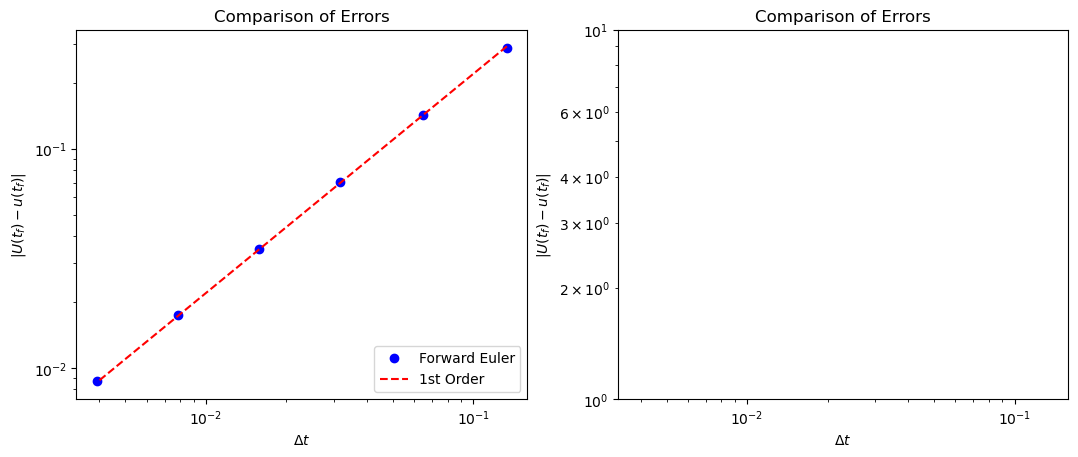

In [11]:
# Membandingkan akurasi metode Euler

f = lambda t, lam, u: lam * (u - numpy.cos(t)) - numpy.sin(t)  
# fungsi diferensial f(t,u) yang akan diselesaikan

u_exact = lambda t: numpy.cos(t)  
# solusi eksak dari persamaan diferensial

t_f = 2.0  
# waktu akhir simulasi

num_steps = [2**n for n in range(4, 10)]  
# jumlah langkah waktu N = 2^n dari n=4 sampai n=9

# num_steps = [2**n for n in range(15,20)]
# alternatif jumlah langkah jika ingin langkah lebih kecil

delta_t = numpy.empty(len(num_steps))  
# array untuk menyimpan ukuran langkah waktu (Δt)

error_10 = numpy.empty(len(num_steps))  
# array untuk menyimpan error saat λ = -10

error_2100 = numpy.empty(len(num_steps))  
# array untuk menyimpan error saat λ = -2100

for (i, N) in enumerate(num_steps):  
    # perulangan untuk setiap jumlah langkah waktu

    t = numpy.linspace(0, t_f, N)  
    # membuat grid waktu dari 0 sampai t_f sebanyak N titik

    delta_t[i] = t[1] - t[0]  
    # menghitung ukuran langkah waktu Δt
    
    # ===============================
    # Menghitung solusi metode Euler
    # ===============================
    
    U = numpy.empty(t.shape)  
    # array untuk menyimpan solusi numerik

    U[0] = 1.0  
    # kondisi awal u(0) = 1

    for (n, t_n) in enumerate(t[1:]):  
        # perulangan metode Euler untuk setiap langkah waktu

        U[n+1] = U[n] + delta_t[i] * f(t_n, -10.0, U[n])  
        # rumus metode Euler maju:
        # U(n+1) = U(n) + Δt * f(t_n , U(n))

    error_10[i] = numpy.abs(U[-1] - u_exact(t_f)) / numpy.abs(u_exact(t_f))  
    # menghitung error relatif pada waktu akhir
    
    # ==================================
    # Menghitung solusi untuk λ = -2100
    # ==================================
    
    U = numpy.empty(t.shape)  
    # membuat ulang array solusi

    U[0] = 1.0  
    # kondisi awal

    for (n, t_n) in enumerate(t[1:]):  

        U[n+1] = U[n] + delta_t[i] * f(t_n, -2100.0, U[n])  
        # metode Euler untuk parameter λ = -2100

    error_2100[i] = numpy.abs(U[-1] - u_exact(t_f)) / numpy.abs(u_exact(t_f))  
    # menghitung error relatif untuk λ = -2100
    

# ==================================
# Membuat grafik error terhadap Δt
# ==================================

fig = plt.figure()  
# membuat objek gambar

fig.set_figwidth(fig.get_figwidth() * 2)  
# memperlebar ukuran gambar

axes = fig.add_subplot(1, 2, 1)  
# subplot pertama (grafik kiri)

axes.loglog(delta_t, error_10, 'bo', label='Forward Euler')  
# plot error vs Δt dalam skala log-log

order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))  
# fungsi untuk membuat garis orde konvergensi

axes.loglog(delta_t, order_C(delta_t[1], error_10[1], 1.0) * delta_t**1.0, 'r--', label="1st Order")  
# menggambar garis referensi orde 1

axes.legend(loc=4)  
# menampilkan legenda grafik

axes.set_title("Comparison of Errors")  
# judul grafik

axes.set_xlabel("$\Delta t$")  
# label sumbu x (langkah waktu)

axes.set_ylabel("$|U(t_f) - u(t_f)|$")  
# label sumbu y (besar error)

# ===============================
# Grafik kedua
# ===============================

axes = fig.add_subplot(1, 2, 2)  
# subplot kedua (grafik kanan)

axes.loglog(delta_t, error_2100, 'bo', label='Forward Euler')  
# plot error untuk λ = -2100

axes.loglog(delta_t, order_C(delta_t[1], error_2100[1], 1.0) * delta_t**1.0, 'r--', label="1st Order")  
# garis referensi orde 1

axes.set_title("Comparison of Errors")  
# judul grafik

axes.set_xlabel("$\Delta t$")  
# label sumbu x

axes.set_ylabel("$|U(t_f) - u(t_f)|$")  
# label sumbu y

plt.show()  
# menampilkan grafik

Jadi, apa yang salah dengan $\lambda = -2100$? Galat global seharusnya mengikuti pola:
$$E^{n+1} = (1 + \Delta t \lambda) E^n - \Delta t T^n$$
Jika $\Delta t \approx 10^{-3}$, maka untuk kasus $\lambda = -10$, galat global sebelumnya dikalikan dengan:$$1 + 10^{-3} \cdot (-10) = 0.99$$yang berarti kontribusi dari $E^n$ akan berkurang secara perlahan seiring kita mengambil lebih banyak langkah waktu. Untuk kasus lainnya, kita mendapatkan:
$$1 + 10^{-3} \cdot (-2100) = -1.1$$
yang berarti bahwa untuk $\Delta t$ ini, galat yang dibuat pada langkah waktu sebelumnya justru akan tumbuh! Agar hal ini tidak terjadi, kita harus memiliki $\Delta t < 2/2100$ (agar $|1 + \Delta t \lambda| < 1$), yang akan membawa kita kembali pada konvergensi.

### **Stabilitas Mutlak dari Metode Euler Eksplisit**
Pertimbangkan kembali masalah uji sederhana 
$$u'(t) = \lambda u$$

Kita tahu dari sebelumnya bahwa menerapkan metode Euler: 

$$
U_{n+1} = U_n + \Delta t \, f(t_n, U_n)
$$

Karena $f(t,u) = \lambda u$, maka:
$$
U_{n+1} = U_n + \Delta t \lambda U_n
$$

Faktorkan $U_n$ sehingga pada masalah ini menghasilkan pembaruan dalam bentuk:

$$U_{n+1} = (1 + \Delta t \lambda) U_n.$$

Dengan menggunakan bentuk rekursif, diperoleh:
$$
U_n = (1 + \Delta t \lambda)^n U_0
$$

Agar metode stabil, solusi numerik harus tetap terbatas saat $n \to \infty$, sehingga:
$$
|U_n| = |(1 + \Delta t \lambda)^n| \, |U_0| \leq |U_0|
$$

sehingga, kita tahu bahwa jika

$$|1 + \Delta t \lambda| \leq 1$$

maka metode tersebut akan stabil; ini disebut stabilitas mutlak. Perhatikan bahwa produk $\Delta t \lambda$ adalah hal yang penting di sini, dan kita sering kali mempertimbangkan wilayah stabilitas mutlak pada bidang kompleks yang didefinisikan oleh persamaan tersebut, di mana sekarang $z = \Delta t \lambda$. Hal ini memungkinkan nilai $\lambda$ menjadi bilangan kompleks, yang merupakan kasus penting untuk dipertimbangkan, terutama untuk sistem persamaan di mana $\lambda$ diidentifikasi sebagai nilai-nilai eigen (eigenvalues).

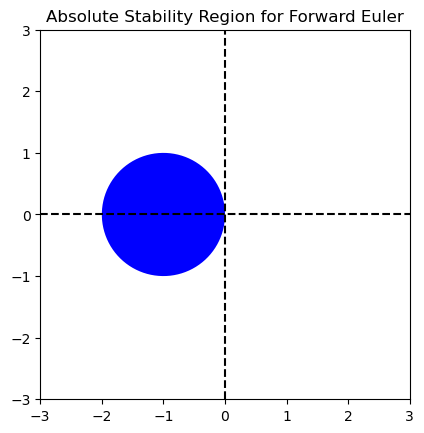

In [12]:
# Membuat grafik daerah kestabilan absolut (Absolute Stability Region)
# untuk metode Forward Euler

fig = plt.figure()  
# membuat objek gambar / figure

axes = fig.add_subplot(1, 1, 1)  
# membuat satu subplot dalam figure

t = numpy.linspace(0.0, 2.0 * numpy.pi, 100)  
# membuat 100 titik dari 0 sampai 2π
# digunakan untuk membentuk kurva lingkaran

axes.fill(numpy.cos(t) - 1.0, numpy.sin(t), 'b')  
# menggambar dan mengisi daerah lingkaran berwarna biru
# pusat lingkaran berada di (-1,0) dengan jari-jari 1
# ini merupakan daerah kestabilan metode Forward Euler

axes.plot([-3, 3],[0.0, 0.0],'k--')  
# menggambar garis putus-putus horizontal (sumbu x)

axes.plot([0.0, 0.0],[-3, 3],'k--')  
# menggambar garis putus-putus vertikal (sumbu y)

axes.set_xlim((-3, 3.0))  
# mengatur batas sumbu x dari -3 sampai 3

axes.set_ylim((-3,3))  
# mengatur batas sumbu y dari -3 sampai 3

axes.set_aspect('equal')  
# mengatur skala sumbu x dan y agar sama
# sehingga bentuk lingkaran tidak berubah

axes.set_title("Absolute Stability Region for Forward Euler")  
# memberi judul grafik

plt.show()  
# menampilkan grafik

### **Wilayah Stabilitas Umum untuk Metode Multistep Linear**
Kembali ke metode multistep linear dan menerapkannya secara umum pada masalah uji kita ($u' = \lambda u$), kita mendapatkan:
$$    \sum^r_{j=0} \alpha_j U_{n+j} = \Delta t \sum^r_{j=0} \beta_j \lambda U_{n+j}$$

 Substitusi Masalah Uji
Gunakan:
$$
u' = \lambda u \;\;\Rightarrow\;\; f(U_{n+j}) = \lambda U_{n+j}
$$

Sehingga:
$$
\sum_{j=0}^{r} \alpha_j U_{n+j}
=
\Delta t \sum_{j=0}^{r} \beta_j \lambda U_{n+j}
$$

 Bentuk Persamaan Homogen
Pindahkan ke satu sisi:
$$
\sum_{j=0}^{r} \alpha_j U_{n+j}
-
\Delta t \sum_{j=0}^{r} \beta_j \lambda U_{n+j}
= 0
$$
Gabungkan:
$$
\sum_{j=0}^{r} (\alpha_j - \beta_j \Delta t \lambda) U_{n+j} = 0
$$

Notasi Sederhana
Misalkan:
$$
z = \Delta t \lambda
$$
atau dengan menggunakan notasi $z = \Delta t \lambda$, kita memiliki:$$    \sum^r_{j=0} (\alpha_j - \beta_j z) U_{n+j} = 0.$$

Ternyata, jika akar-akar $\xi_i$ dari polinomial ini memenuhi 
$$    |\xi_i| \leq 1$$
maka metode multistep tersebut dikatakan stabil mutlak (absolutely-stable). Kita kemudian mendefinisikan wilayah stabilitas mutlak sebagai kumpulan nilai $z$ di mana kondisi ini terpenuhi. Pendekatan ini juga dapat diterapkan pada metode satu-langkah (one-step methods).

##### **Contoh: Metode Forward Euler**

Menelaah metode Forward Euler (Euler Eksplisit), kita memiliki:

$$\begin{aligned}
    0 &= U_{n+1} - U_n - \Delta t \lambda U_n \\
    &= U_{n+1} - U_n (1 + \Delta t \lambda)\\
    &= \xi - 1 (1 + z)\\
    &=\pi(\xi, z)
\end{aligned}$$

yang akarnya adalah $\xi = 1 + z$, dan dengan ini kita telah menurunkan kembali wilayah stabilitas yang telah kita temukan sebelumnya.

### **Stabilitas Mutlak Metode Backward Euler**
Metode Backward Euler didefinisikan sebagai:
$$    U_{n+1} = U_n + \Delta t f(t_{n+1}, U_{n+1}).$$


Pindahkan ke satu sisi:
$$
U_{n+1} - \Delta t \lambda U_{n+1} - U_n = 0
$$

Faktorkan:
$$
(1 - \Delta t \lambda) U_{n+1} - U_n = 0
$$

Sehingga:
$$
0 = U_{n+1}(1 - \Delta t \lambda) - U_n
$$

Definisikan:
$$
\xi = \frac{U_{n+1}}{U_n}, \quad z = \Delta t \lambda
$$

Bagi dengan $U_n$:
$$
0 = \xi (1 - z) - 1
$$

Sehingga:
$$
\xi = \frac{1}{1 - z}
$$

Syarat stabilitas:
$$
\left|\frac{1}{1 - z}\right| \leq 1 \iff |1 - z| \geq 1
$$


Jadi, faktanya wilayah stabilitas ini mencakup seluruh bidang kompleks kecuali sebuah lingkaran yang berpusat di $(1, 0)$ dengan jari-jari 1. Ini menyiratkan bahwa metode Backward Euler sebenarnya stabil untuk pilihan $\Delta t$ berapa pun (selama $\text{Re}(z) \leq 0$).

### **Penerapan pada ODE Kaku (Stiff)**
Pertimbangkan kembali ODE yang kita periksa sebelumnya:

$$u'(t) = \lambda (u - \cos t) - \sin t$$
 Sederhanakan
$$
u'(t) = \lambda u - \lambda \cos t - \sin t
$$
 Bentuk Linear Standar
$$
u'(t) - \lambda u = -\lambda \cos t - \sin t
$$
 Faktor Integrasi
$$
\mu(t) = e^{-\lambda t}
$$
Kalikan Faktor Integrasi
$$
e^{-\lambda t} u'(t) - \lambda e^{-\lambda t} u
= (-\lambda \cos t - \sin t)e^{-\lambda t}
$$
 Bentuk Turunan
$$
\frac{d}{dt}\left(e^{-\lambda t} u\right)
= (-\lambda \cos t - \sin t)e^{-\lambda t}
$$
 Substitusi
$$
\frac{d}{dt}\left(e^{-\lambda t} \cos t\right)
= (-\lambda \cos t - \sin t)e^{-\lambda t}
$$
 Samakan
$$
\frac{d}{dt}\left(e^{-\lambda t} u\right)
= \frac{d}{dt}\left(e^{-\lambda t} \cos t\right)
$$
 Integrasi
$$
e^{-\lambda t} u = e^{-\lambda t} \cos t + C
$$

 Gunakan Kondisi Awal
$$
u(t) = \cos t + C e^{\lambda t}
$$

$$
u(t_0) = \eta
$$

$$
\eta = \cos t_0 + C e^{\lambda t_0}
$$

$$
C = e^{-\lambda t_0} (\eta - \cos t_0)
$$
substitusikan: 
$$
u(t) = \cos t + e^{\lambda t} \cdot e^{-\lambda t_0} \, (\eta - \cos t_0)
$$
$$
u(t) = \cos t + e^{\lambda (t - t_0)} (\eta - \cos t_0)
$$
sehingga:
$$u(t) = e^{\lambda (t - t_0)} (\eta - \cos t_0) + \cos t$$

<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
C:\Users\HP\AppData\Local\Temp\ipykernel_13592\2856370874.py:42: SyntaxWarning: invalid escape sequence '\l'
  axes.set_title("Perturbed Solutions $\lambda = %s$" % lam)


<Figure size 640x480 with 0 Axes>

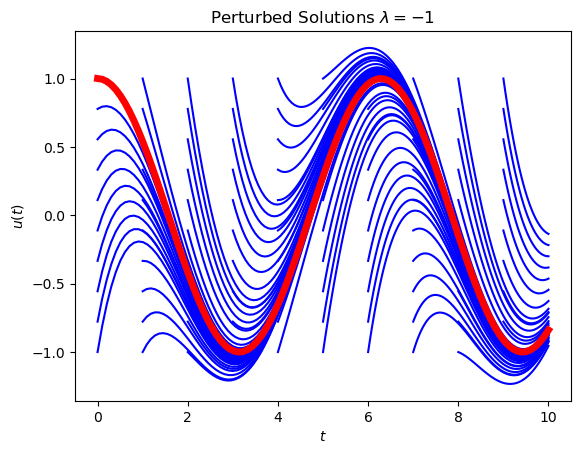

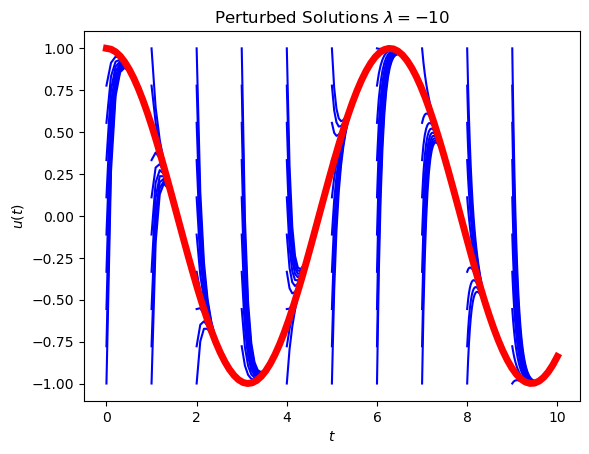

In [13]:
# Membuat grafik banyak solusi ("hairy solutions") dari suatu ODE
# Solusi ini menunjukkan bagaimana solusi berubah jika kondisi awal diganggu (perturbasi)

u = lambda t_0, eta, lam, t: numpy.exp(lam * (t - t_0)) * (eta - numpy.cos(t_0)) + numpy.cos(t)
# fungsi solusi analitik dari persamaan diferensial
# t_0  = waktu awal
# eta  = nilai kondisi awal yang diganggu
# lam  = parameter lambda
# t    = waktu

fig = plt.figure()
# membuat objek figure

for lam in [-1, -10]:
    # melakukan perulangan untuk dua nilai lambda
    # λ = -1 dan λ = -10
    
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)
    # membuat satu subplot
    
    for eta in numpy.linspace(-1, 1, 10):
        # membuat 10 variasi kondisi awal dari -1 sampai 1
        
        for t_0 in numpy.linspace(0.0, 9.0, 10):
            # membuat 10 variasi waktu awal
            
            t = numpy.linspace(t_0,10.0,100)
            # membuat grid waktu dari t0 sampai 10
            
            axes.plot(t, u(t_0, eta, lam, t),'b')
            # menggambar solusi yang terganggu (perturbed solution)
            # garis berwarna biru

    t = numpy.linspace(0.0,10.0,100)
    # membuat waktu dari 0 sampai 10
    
    axes.plot(t, numpy.cos(t), 'r', linewidth=5)
    # menggambar solusi utama (solusi eksak)
    # garis merah tebal
        
    axes.set_title("Perturbed Solutions $\lambda = %s$" % lam)
    # memberi judul grafik sesuai nilai lambda
    
    axes.set_xlabel('$t$')
    # memberi label sumbu x (waktu)
    
    axes.set_ylabel('$u(t)$')
    # memberi label sumbu y (nilai solusi)

plt.show()
# menampilkan semua grafik

<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\l'
C:\Users\HP\AppData\Local\Temp\ipykernel_13592\1782501582.py:62: SyntaxWarning: invalid escape sequence '\l'
  axes.set_title("Perturbed Solutions $\lambda = %s$" % lam)


<Figure size 640x480 with 0 Axes>

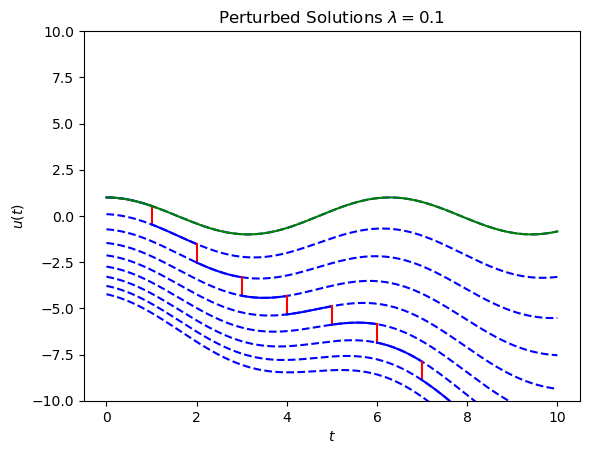

In [14]:
# Membuat grafik "inverse hairy solutions" dari suatu ODE
# Grafik ini menunjukkan solusi yang terus diberi gangguan (perturbasi)
# pada setiap langkah waktu

u = lambda t_0, eta, lam, t: numpy.exp(lam * (t - t_0)) * (eta - numpy.cos(t_0)) + numpy.cos(t)
# fungsi solusi analitik dari persamaan diferensial
# t_0  = waktu awal
# eta  = kondisi awal yang terganggu
# lam  = parameter lambda
# t    = waktu

fig = plt.figure()

num_steps = 10
# jumlah langkah waktu yang akan dibagi

error = numpy.ones(num_steps) * 1.0
# array error yang digunakan sebagai gangguan pada solusi

t_hat = numpy.linspace(0.0, 10.0, num_steps + 1)
# membagi interval waktu 0 sampai 10 menjadi beberapa bagian

t_whole = numpy.linspace(0.0, 10.0, 1000)
# grid waktu penuh dari 0 sampai 10 untuk menampilkan solusi teoritis

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
# membuat satu subplot

eta = 1.0
# kondisi awal

lam = 0.1
# nilai parameter lambda

for n in range(1,num_steps):
    # perulangan untuk setiap interval waktu
    
    t = numpy.linspace(t_hat[n-1], t_hat[n], 100)
    # membuat grid waktu pada interval tertentu
    
    U = u(t_hat[n-1], eta, lam, t)
    # menghitung solusi pada interval tersebut
    
    axes.plot(t, U, 'b')
    # menggambar solusi aktual pada interval (garis biru)
    
    axes.plot(t_whole, u(t_hat[n-1], eta, lam, t_whole),'b--')
    # menggambar solusi teoritis dengan garis putus-putus
    
    axes.plot([t[-1], t[-1]], (U[-1], U[-1] + -1.0**n * error[n]), 'r')
    # menggambar garis merah yang menunjukkan gangguan error
    
    eta = U[-1] + -1.0**n * error[n]
    # memperbarui kondisi awal dengan menambahkan gangguan

t = numpy.linspace(0.0, 10.0, 100)

axes.plot(t, numpy.cos(t), 'g')
# menggambar solusi eksak u(t) = cos(t) dengan garis hijau

axes.set_title("Perturbed Solutions $\lambda = %s$" % lam)
# memberi judul grafik

axes.set_xlabel('$t$')
# label sumbu x (waktu)

axes.set_ylabel('$u(t)$')
# label sumbu y (nilai solusi)

axes.set_ylim((-10,10))
# mengatur batas tampilan sumbu y

plt.show()
# menampilkan grafik

##### **Contoh: Sistem Kimia**

Pertimbangkan transisi dari zat kimia $A$ menjadi zat kimia $C$ melalui proses berikut:

$$A \overset{K_1}{\rightarrow} B \overset{K_2}{\rightarrow} C.$$

Jika kita misalkan

$$\vec{u} = \begin{bmatrix} [A] \\ [B] \\ [C] \end{bmatrix}$$

maka kita dapat memodelkan reaksi kimia sederhana ini dengan sistem ODE:

$$\frac{\text{d} \vec{u}}{\text{d} t} = 
\begin{bmatrix}
    -K_1 & 0 & 0 \\
    K_1 & -K_2 & 0 \\
    0 & K_2 & 0
\end{bmatrix} \vec{u}$$

Solusi dari sistem ini berbentuk:

$$u_j(t) = c_{j1} e^{-K_1 t} + c_{j2}e^{-K_2 t} + c_{j3}$$

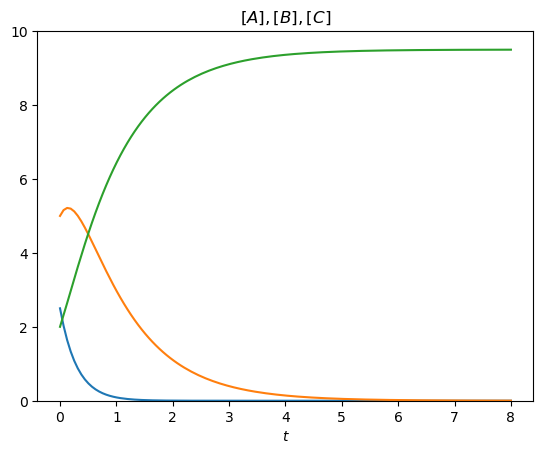

In [15]:
# Menyelesaikan contoh sistem reaksi kimia menggunakan metode Euler

# =========================
# Parameter masalah
# =========================

K_1 = 3
K_2 = 1
# konstanta laju reaksi kimia

# K_1 = 30.0
# K_2 = 1.0
# alternatif nilai konstanta jika ingin mencoba kasus lain

# =========================
# Matriks sistem reaksi
# =========================

A = numpy.array([[-K_1, 0, 0], 
                 [K_1, -K_2, 0], 
                 [0, K_2, 0]])
# matriks koefisien sistem diferensial
# menggambarkan perubahan konsentrasi zat A, B, dan C

f = lambda u: numpy.dot(A, u)
# fungsi sistem ODE dalam bentuk vektor
# f(u) = A * u

# =========================
# Grid waktu
# =========================

t = numpy.linspace(0.0, 8.0, 128)
# membuat waktu dari 0 sampai 8 dengan 128 titik

delta_t = t[1] - t[0]
# menghitung ukuran langkah waktu Δt

# =========================
# Inisialisasi solusi
# =========================

U = numpy.empty((t.shape[0], 3))
# membuat array untuk menyimpan solusi
# 3 kolom mewakili konsentrasi A, B, dan C

U[0, :] = [2.5, 5.0, 2.0]
# kondisi awal konsentrasi
# [A], [B], [C]

# =========================
# Metode Euler maju
# =========================

for n in range(t.shape[0] - 1):
    # perulangan untuk setiap langkah waktu
    
    U[n+1, :] = U[n, :] + delta_t * f(U[n, :])
    # rumus metode Euler:
    # U(n+1) = U(n) + Δt * f(U(n))

# =========================
# Membuat grafik hasil
# =========================

fig = plt.figure()

axes = fig.add_subplot(1, 1, 1)
# membuat satu subplot

axes.plot(t, U)
# menggambar perubahan konsentrasi A, B, dan C terhadap waktu

axes.set_title("Chemical System")
# judul grafik

axes.set_xlabel("$t$")
# label sumbu x (waktu)

axes.set_title("$[A], [B], [C]$")
# label untuk konsentrasi zat kimia

axes.set_ylim((0.0, 10.))
# mengatur batas sumbu y

plt.show()
# menampilkan grafik

### **Apa itu Kekakuan (Stiffness)?**

Secara umum, sebuah ODE dikatakan kaku (stiff) jika $u'(t) \ll f'(t, u)$. Ini berarti solusi $u(t)$ berubah secara perlahan, namun fungsi $f(t, u)$ sangat sensitif terhadap perubahan kecil pada $u$. Untuk sistem ODE, rasio kekakuan (stiffness ratio):

$$\frac{\max_p |\lambda_p|}{\min_p |\lambda_p|}$$

dapat digunakan untuk mencirikan kekakuan sistem tersebut. Dalam contoh kinetika kimia kita sebelumnya, rasio ini adalah $K_1 / K_2$ (jika $K_1 > K_2$). Seiring kita meningkatkan rasio ini, kita mengamati bahwa metode numerik menjadi tidak stabil; hanya pengurangan $\Delta t$ yang dapat membawa solusi kembali stabil.Bagi metode langkah waktu eksplisit (explicit time step methods), hal ini sangat bermasalah karena pengurangan langkah waktu hanya demi satu spesies (atau satu komponen yang berubah cepat) menyebabkan evaluasi yang sangat mahal secara komputasi. Sebagai contoh, metode Forward Euler memiliki kriteria stabilitas:

$$|1 + \Delta t \lambda| < 1$$

di mana $\lambda$ harus merupakan nilai eigen maksimum ($\lambda_{max}$) dari sistem tersebut.

-3.0
-1.0


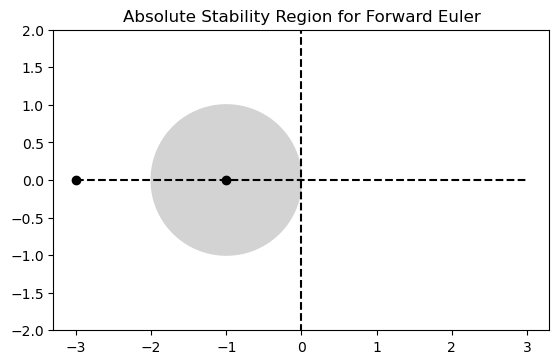

In [16]:
# Membuat grafik daerah kestabilan absolut (Absolute Stability Region)
# untuk metode Forward Euler dan menampilkan eigenvalue sistem

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
# membuat satu subplot pada figure

t = numpy.linspace(0.0, 2.0 * numpy.pi, 100)
# membuat 100 titik dari 0 sampai 2π
# digunakan untuk membentuk lingkaran daerah kestabilan

# =========================
# Parameter sistem
# =========================

K_1 = 3.0
K_2 = 1.0
# konstanta reaksi atau parameter sistem

delta_t = 1.0
# ukuran langkah waktu (Δt)

eigenvalues = [-K_1, -K_2]
# eigenvalue dari sistem diferensial

# =========================
# Daerah kestabilan Euler
# =========================

axes.fill(numpy.cos(t) - 1.0, numpy.sin(t), color='lightgray')
# menggambar daerah kestabilan metode Forward Euler
# berbentuk lingkaran dengan pusat (-1,0) dan jari-jari 1

# =========================
# Menampilkan posisi eigenvalue
# =========================

for lam in eigenvalues:
    print(lam * delta_t)
    # mencetak nilai λΔt
    
    axes.plot(lam * delta_t, 0.0, 'ko')
    # menampilkan titik eigenvalue pada grafik

# =========================
# Menggambar sumbu koordinat
# =========================

axes.plot([-3, 3],[0.0, 0.0],'k--')
# garis putus-putus untuk sumbu x

axes.plot([0.0, 0.0],[-3, 3],'k--')
# garis putus-putus untuk sumbu y

# axes.set_xlim((-3, 1))
# pengaturan batas sumbu x (opsional)

axes.set_ylim((-2,2))
# mengatur batas sumbu y

axes.set_aspect('equal')
# membuat skala sumbu x dan y sama agar lingkaran tidak terdistorsi

axes.set_title("Absolute Stability Region for Forward Euler")
# judul grafik

plt.show()
# menampilkan grafik

### **Stabilitas-A (A-Stability)**

Bagaimana jika kita dapat memperluas wilayah stabilitas mutlak untuk mencakup lebih banyak bagian dari setengah bidang kiri (left-half plane), atau bahkan lebih baik lagi, seluruhnya? Sebuah metode yang memiliki properti ini disebut sebagai A-stable. Kita telah melihat satu contoh metode ini pada Backward Euler yang memiliki wilayah stabilitas:

$$|1 - z| \geq 1$$

yang mencakup seluruh setengah bidang kiri kompleks.

Ternyata, untuk metode multistep linear (LMM), sebuah teorema oleh Dahlquist membuktikan bahwa tidak ada LMM yang memenuhi kriteria stabilitas-A (A-stability) di atas orde kedua (aturan trapesium). Namun, terdapat metode Runge-Kutta orde tinggi yang memenuhi kriteria tersebut.

Namun, mungkin kriteria ini terlalu membatasi. Sering kali, nilai-nilai eigen yang besar dalam suatu sistem (misalnya yang berasal dari diskritisasi PDE untuk persamaan panas) terletak sepenuhnya pada garis riil. Jika wilayah stabilitas dapat mencakup sebanyak mungkin garis riil tersebut sambil mengabaikan sisa dari setengah bidang kiri, kita mungkin bisa mendapatkan metode yang lebih efisien. Terdapat sejumlah metode yang dapat dirancang dengan properti ini namun memiliki orde yang lebih tinggi.

-3.0
-1.0


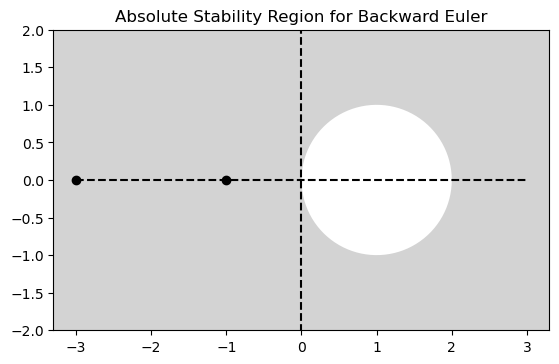

In [17]:
# Membuat grafik daerah kestabilan absolut (Absolute Stability Region)
# untuk metode Backward Euler

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
# membuat satu subplot pada figure

t = numpy.linspace(0.0, 2.0 * numpy.pi, 100)
# membuat 100 titik dari 0 sampai 2π
# digunakan untuk membentuk lingkaran

# =========================
# Parameter sistem
# =========================

K_1 = 3.0
K_2 = 1.0
# konstanta sistem

delta_t = 1.0
# ukuran langkah waktu Δt

eigenvalues = [-K_1, -K_2]
# eigenvalue dari sistem diferensial

# =========================
# Daerah kestabilan Backward Euler
# =========================

axes.set_facecolor('lightgray')
# memberi warna latar belakang abu-abu
# bagian ini merupakan daerah stabil

axes.fill(numpy.cos(t) + 1.0, numpy.sin(t), 'w')
# menggambar lingkaran berwarna putih dengan pusat (1,0)
# daerah di dalam lingkaran merupakan daerah tidak stabil
# sedangkan luar lingkaran stabil untuk Backward Euler

# =========================
# Menampilkan posisi eigenvalue
# =========================

for lam in eigenvalues:
    print(lam * delta_t)
    # mencetak nilai λΔt
    
    axes.plot(lam * delta_t, 0.0, 'ko')
    # menampilkan titik eigenvalue pada grafik

# =========================
# Menggambar sumbu koordinat
# =========================

axes.plot([-3, 3],[0.0, 0.0],'k--')
# garis putus-putus untuk sumbu x

axes.plot([0.0, 0.0],[-3, 3],'k--')
# garis putus-putus untuk sumbu y

# axes.set_xlim((-3, 1))
# pengaturan batas sumbu x (opsional)

axes.set_ylim((-2,2))
# mengatur batas sumbu y

axes.set_aspect('equal')
# membuat skala sumbu x dan y sama agar lingkaran tidak terdistorsi

axes.set_title("Absolute Stability Region for Backward Euler")
# judul grafik

plt.show()
# menampilkan grafik

### **L-Stability (Stabilitas-L)**
Ternyata tidak semua metode yang bersifat A-stable itu serupa. Mari kita tinjau metode Backward Euler dan metode Trapezoidal. Polinomial stabilitas untuk metode trapezoidal adalah:

$$
U_{n+1} = U_n + \Delta t \frac{1}{2} (\lambda U_n + \lambda U_{n+1})
$$

Pindahkan semua ke satu sisi:
$$
U_{n+1} - U_n - \Delta t \frac{1}{2} (\lambda U_n + \lambda U_{n+1}) = 0
$$

Kelompokkan suku:
$$
U_{n+1} - \frac{1}{2} \Delta t \lambda U_{n+1}
- U_n - \frac{1}{2} \Delta t \lambda U_n = 0
$$

Faktorkan:
$$
U_{n+1}\left(1 - \frac{1}{2} \Delta t \lambda \right)
- U_n \left(1 + \frac{1}{2} \Delta t \lambda \right) = 0
$$

Sehingga:
$$
0 = U_{n+1}\left(1 - \frac{1}{2} \Delta t \lambda \right)
- U_n \left(1 + \frac{1}{2} \Delta t \lambda \right)
$$

Definisikan:
$$
\xi = \frac{U_{n+1}}{U_n}, \quad z = \Delta t \lambda
$$

Bagi dengan $U_n$:
$$
0 = \xi \left(1 - \frac{1}{2} z \right)
- \left(1 + \frac{1}{2} z \right)
$$

Sehingga:
$$
\xi = \frac{1 + \frac{1}{2} z}{1 - \frac{1}{2} z}
$$


yang menunjukkan bahwa metode ini bersifat A-stable. Mari kita terapkan kedua metode ini pada masalah yang telah kita pelajari sebelumnya dan lihat apa yang terjadi.

<>:114: SyntaxWarning: invalid escape sequence '\D'
<>:153: SyntaxWarning: invalid escape sequence '\D'
<>:114: SyntaxWarning: invalid escape sequence '\D'
<>:153: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HP\AppData\Local\Temp\ipykernel_13592\4260274169.py:114: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta t$")
C:\Users\HP\AppData\Local\Temp\ipykernel_13592\4260274169.py:153: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta t$")


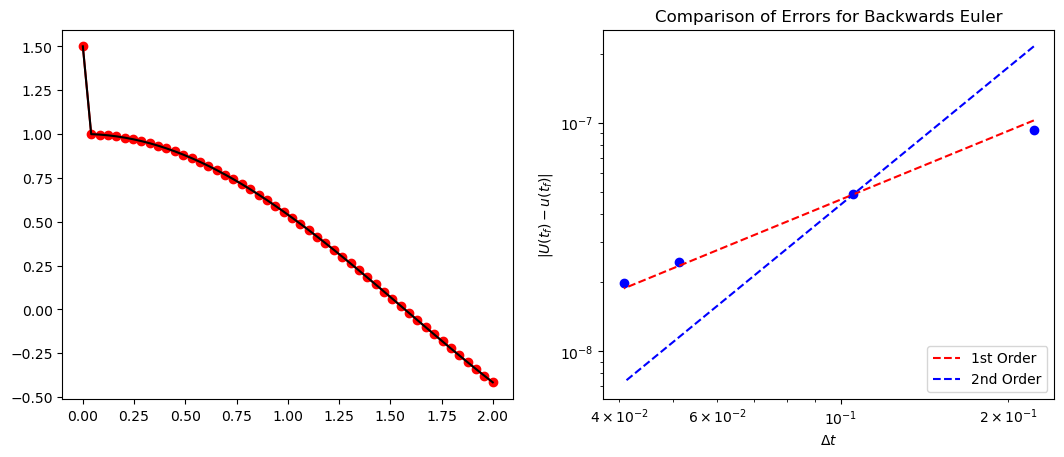

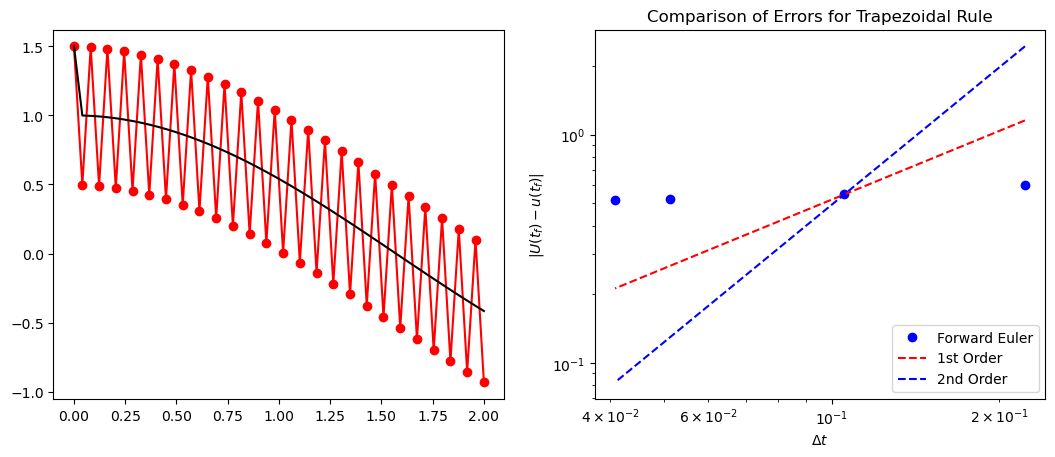

In [18]:
# Membandingkan akurasi metode Backward Euler dan metode Trapezoidal

f = lambda t, lam, u: lam * (u - numpy.cos(t)) - numpy.sin(t)
# fungsi persamaan diferensial f(t,u)

u_exact = lambda t_0, eta, lam, t: numpy.exp(lam * (t - t_0)) * (eta - numpy.cos(t_0)) + numpy.cos(t)
# solusi eksak dari persamaan diferensial

t_0 = 0.0
# waktu awal

eta = 1.5
# kondisi awal u(t0)

lam = -1e6
# parameter lambda (nilai sangat besar negatif → sistem sangat kaku / stiff)

num_steps = [10, 20, 40, 50]
# jumlah langkah waktu yang akan digunakan

delta_t = numpy.empty(len(num_steps))
# array untuk menyimpan ukuran langkah waktu Δt

error_euler = numpy.empty(len(num_steps))
# array untuk menyimpan error metode Backward Euler

error_trap = numpy.empty(len(num_steps))
# array untuk menyimpan error metode Trapezoidal

for (i, N) in enumerate(num_steps):
    
    t = numpy.linspace(0, t_f, N)
    # membuat grid waktu dari 0 sampai waktu akhir
    
    delta_t[i] = t[1] - t[0]
    # menghitung ukuran langkah waktu
    
    u = u_exact(t_0, eta, lam, t_f)
    # menghitung solusi eksak pada waktu akhir
    
    # =========================
    # Menghitung solusi Backward Euler
    # =========================
    
    U_euler = numpy.empty(t.shape)
    # array solusi numerik
    
    U_euler[0] = eta
    # kondisi awal
    
    for (n, t_n) in enumerate(t[1:]):
        
        U_euler[n+1] = (U_euler[n] - lam * delta_t[i] * numpy.cos(t_n) - delta_t[i] * numpy.sin(t_n)) / (1.0 - lam * delta_t[i])
        # rumus metode Backward Euler
    
    error_euler[i] = numpy.abs(U_euler[-1] - u) / numpy.abs(u)
    # menghitung error relatif metode Backward Euler
    
    # =========================
    # Menghitung solusi metode Trapezoidal
    # =========================
    
    U_trap = numpy.empty(t.shape)
    # array solusi numerik
    
    U_trap[0] = eta
    # kondisi awal
    
    for (n, t_n) in enumerate(t[1:]):
        
        U_trap[n+1] = (U_trap[n] + delta_t[i] * 0.5 * f(t_n, lam, U_trap[n]) 
                       - 0.5 * lam * delta_t[i] * numpy.cos(t_n) 
                       - 0.5 * delta_t[i] * numpy.sin(t_n)) / (1.0 - 0.5 * lam * delta_t[i])
        # rumus metode Trapezoidal
    
    error_trap[i] = numpy.abs(U_trap[-1] - u)
    # menghitung error metode trapezoidal
    
# =========================
# Grafik hasil Backward Euler
# =========================

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
# memperlebar ukuran gambar

axes = fig.add_subplot(1, 2, 1)

axes.plot(t, U_euler, 'ro-')
# solusi numerik Backward Euler

axes.plot(t, u_exact(t_0, eta, lam, t),'k')
# solusi eksak

axes = fig.add_subplot(1, 2, 2)

axes.loglog(delta_t, error_euler, 'bo')
# grafik error terhadap Δt dalam skala log-log

order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
# fungsi untuk membuat garis orde konvergensi

axes.loglog(delta_t, order_C(delta_t[1], error_euler[1], 1.0) * delta_t**1.0, 'r--', label="1st Order")
# garis referensi orde 1

axes.loglog(delta_t, order_C(delta_t[1], error_euler[1], 2.0) * delta_t**2.0, 'b--', label="2nd Order")
# garis referensi orde 2

axes.legend(loc=4)

axes.set_title("Comparison of Errors for Backwards Euler")
# judul grafik

axes.set_xlabel("$\Delta t$")
# label sumbu x

axes.set_ylabel("$|U(t_f) - u(t_f)|$")
# label sumbu y

# =========================
# Grafik hasil metode Trapezoidal
# =========================

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)

axes = fig.add_subplot(1, 2, 1)

axes.plot(t, U_trap, 'ro-')
# solusi numerik metode trapezoidal

axes.plot(t, u_exact(t_0, eta, lam, t),'k')
# solusi eksak

axes = fig.add_subplot(1, 2, 2)

axes.loglog(delta_t, error_trap, 'bo', label='Forward Euler')
# grafik error metode trapezoidal

order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))

axes.loglog(delta_t, order_C(delta_t[1], error_trap[1], 1.0) * delta_t**1.0, 'r--', label="1st Order")
# garis referensi orde 1

axes.loglog(delta_t, order_C(delta_t[1], error_trap[1], 2.0) * delta_t**2.0, 'b--', label="2nd Order")
# garis referensi orde 2

axes.legend(loc=4)

axes.set_title("Comparison of Errors for Trapezoidal Rule")
# judul grafik

axes.set_xlabel("$\Delta t$")
# label sumbu x

axes.set_ylabel("$|U(t_f) - u(t_f)|$")
# label sumbu y

plt.show()
# menampilkan grafik

### **Definisi L-Stability**
Ternyata jika kita meninjau metode satu-langkah (one-step method) dan mendefinisikan rasio berikut:

$$U_{n+1} = R(z) U_n$$

kita dapat mendefinisikan bentuk stabilitas lainnya yang disebut sebagai L-stability, di mana kita mensyaratkan bahwa metode tersebut haruslah A-stable dan memenuhi:

$$\lim_{z \rightarrow \infty} |R(z)| = 0.$$

**Contoh**

**Backward Euler:**
$$
R(z) = \frac{1}{1 - z}
$$

$$
\lim_{z \to \infty} \left| \frac{1}{1 - z} \right| = 0
$$

Sehingga metode ini **L-stable**.

**Trapezoidal:**
$$
R(z) = \frac{1 + \frac{1}{2}z}{1 - \frac{1}{2}z}
$$

$$
\lim_{z \to \infty} \left| \frac{1 + \frac{1}{2}z}{1 - \frac{1}{2}z} \right| = 1
$$

Sehingga metode ini **tidak L-stable**.  
Metode Backward Euler bersifat L-stable, sedangkan metode trapezoidal tidak.

### **Rumus Diferensiasi Mundur (Backward Differencing Formulas - BDF)**
Salah satu kelas metode LMM (Linear Multi-Step Methods) yang berguna untuk masalah ODE kaku (stiff) adalah metode Backward Difference Formula (BDF) yang memiliki bentuk:

$$\alpha_0 U_n + \alpha_1 U_{n+1} + \cdots + \alpha_r U_{n+r} = \Delta t \beta_r f(U_{n+r})$$

Metode-metode ini dapat diturunkan secara langsung dari beda hingga mundur (backwards finite differences) dari titik $U_{n+r}$ dan titik-titik lainnya di waktu sebelumnya. Dengan cara ini, seseorang dapat menurunkan metode $r$-langkah yang memiliki tingkat akurasi orde ke-$r$. Beberapa dari metode tersebut adalah:

$$\begin{aligned}
    r = 1:& & U_{n+1} - U_n = \Delta t f(U_{n+1}) \\
    r = 2:& &3 U_{n+2} - 4 U_{n+1} + U_n = 2 \Delta t f(U_{n+2}) \\
    r = 3:& &11U_{n+3} - 18U_{n+2} + 9U_{n+1} - 2 U_n = 6 \Delta t f(U_{n+3}) \\
    r = 4:& &25 U_{n+4} - 48 U_{n+3} +36 U_{n+2} -16 U_{n+1} +3 U_n = 12 \Delta t f(U_{n+4})\end{aligned}$$

### **Memplot Daerah Stabilitas**
Jika kita menganggap akar-akar dari polinomial stabilitas $\xi_j$ sebagai bilangan kompleks dan menulisnya dalam bentuk eksponensial:

$$    \xi_j = |\xi_j| e^{i \theta}.$$

di mana $|\xi_j|$ adalah modulus dari bilangan kompleks:
$$
|\xi_j| = \sqrt{x^2 + y^2}, \quad \text{dengan } \xi_j = x + iy
$$

Jika $\xi_j$ berada pada batas wilayah stabilitas absolut, maka:
$$
|\xi_j| = 1
$$

Dengan menggunakan kondisi ini pada polinomial stabilitas, diperoleh:
$$
\rho(e^{i\theta}) - z \, \sigma(e^{i\theta}) = 0
$$

Sehingga:
$$
z(\theta) = \frac{\rho(e^{i\theta})}{\sigma(e^{i\theta})}
$$

Sebagai contoh, pertimbangkan metode Adams-Bashforth 2-tahap (AB2). Polinomial stabilitasnya dapat ditemukan sebagai:
$$\begin{aligned}
    U_{n+2} &= U_{n+1} + \frac{\Delta t}{2} (-f(U_n) + 3 f(U_{n+1})) \\
    \pi(\xi, z) &= U_{n+2} - U_{n+1} - \frac{\Delta t}{2} (-f(U_n) + 3 f(U_{n+1})) = 0 \\
    &= U_{n+2} - U_{n+1} - \frac{1}{2} (\Delta t \lambda U_n - 3 \Delta t \lambda U_{n+1}) \\
    &= 2 \xi^2 - 2 \xi + 3 z\xi - z \\
    &= \rho(\xi, z) + z \sigma(\xi, z)
\end{aligned}$$
dimana 
$$
    \rho(\xi, z) = 2 ( \xi - 1) \xi ~~~ \text{and} ~~~ \sigma(\xi, z) = 3 \xi - 1
$$
sehinga 
$$
    z(\theta) = \frac{2 (\xi - 1) \xi}{3 \xi - 1}.
$$

Hal ini tidak serta-merta menjamin bahwa untuk suatu $\theta$ tertentu, $z(\theta)$ akan terletak pada batas wilayah stabilitas absolut. Hal ini dapat terjadi ketika $|\xi_j| = 1$, namun di sisi kiri dan kanan kurva tersebut $|\xi_j| > 1$, sehingga kurva tersebut tidak menandai batas wilayahnya. Untuk menentukan apakah suatu wilayah tertentu yang digariskan oleh kurva ini berada di dalam atau di luar wilayah stabilitas, kita dapat mengevaluasi semua akar dari $\pi(\xi, z)$ pada suatu titik $z$ di dalam wilayah yang dimaksud dan melihat apakah memenuhi $\forall j, |\xi_j| < 1$.

Untuk metode satu-langkah (one-step methods), hal ini menjadi lebih mudah; jika kita melihat rasio $R(z)$ yang kita definisikan sebelumnya sebagai:
$$
U_{n+1} = R(z) U_n
$$

Contoh: metode deret Taylor orde-$p$

$$
\begin{aligned}
U_{n+1} &= U_n + \Delta t \lambda U_n + \frac{1}{2}\Delta t^2 \lambda^2 U_n + \cdots + \frac{1}{p!}\Delta t^p \lambda^p U_n \\
&= \left(1 + z + \frac{1}{2} z^2 + \frac{1}{6} z^3 + \cdots + \frac{1}{p!} z^p \right) U_n
\end{aligned}
$$

Sehingga:
$$
R(z) = 1 + z + \frac{1}{2} z^2 + \frac{1}{6} z^3 + \cdots + \frac{1}{p!} z^p
$$


Menetapkan $R(z) = e^{i\theta}$ dapat menjadi salah satu cara untuk menyelesaikan batas wilayah stabilitas (di mana $|R(z)| = 1$), namun hal ini sangat sulit dilakukan secara umum. Sebagai gantinya, jika kita memplot kontur dari $|R(z)|$ pada bidang kompleks, kita dapat memilih kontur $|R(z)| = 1$ dan memplotnya sebagai batas tersebut.

Forward Euler's method - Stability region tests
  Inside of circle:  0.0
  Outside of circle:  2.0
Backward Euler's method - Stability region tests
  Inside of circle:  2.0
  Outside of circle:  0.0
Taylor series method of order 4 - Stability region tests
  Inside of strange region:  0.0
  Outside of strange region:  3.0


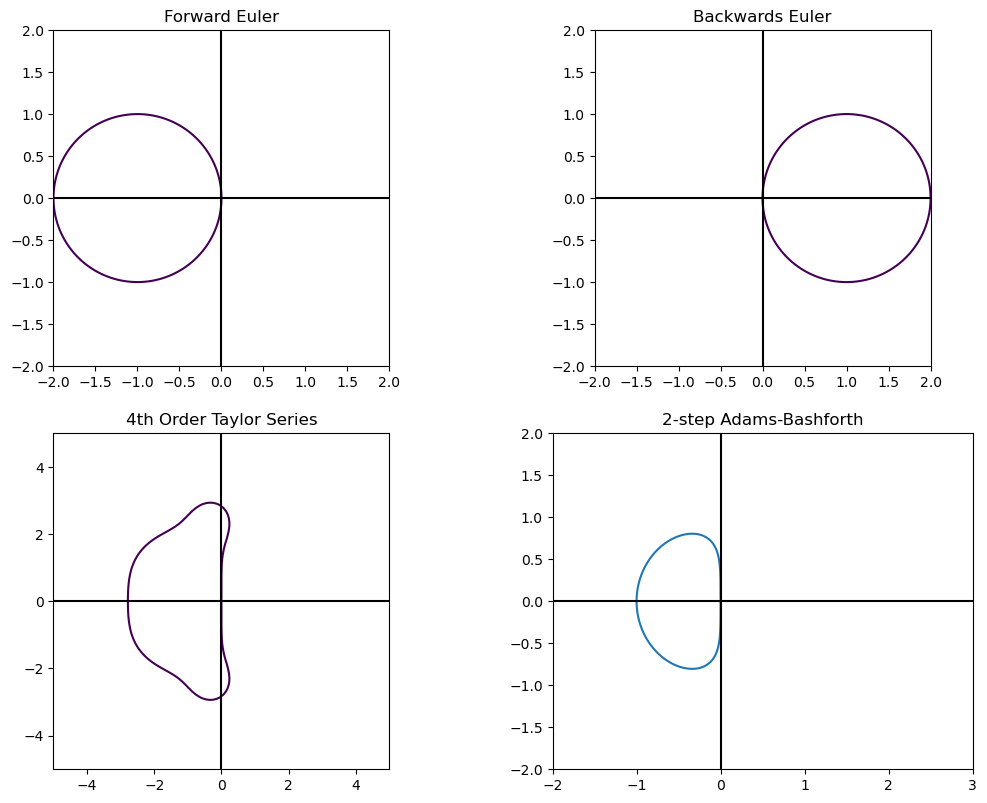

In [19]:
theta = numpy.linspace(0.0, 2.0 * numpy.pi, 100)
# membuat nilai sudut dari 0 sampai 2π

# ==================================
# Forward Euler
# ==================================

fig = plt.figure()
# membuat objek figure

fig.set_figwidth(fig.get_figwidth() * 2.0)
fig.set_figheight(fig.get_figheight() * 2.0)
# memperbesar ukuran figure

axes = fig.add_subplot(2, 2, 1)
# subplot pertama (baris 1 kolom 1)

x = numpy.linspace(-2, 2, 100)
y = numpy.linspace(-2, 2, 100)
# membuat grid sumbu x dan y

X, Y = numpy.meshgrid(x, y)
# membuat mesh grid untuk bidang 2D

Z = X + 1j * Y
# membentuk bilangan kompleks Z = x + iy

# Mengecek apakah titik berada di daerah stabil
print("Forward Euler's method - Stability region tests")

z = -1 + 1j * 0
print("  Inside of circle: ", numpy.abs(1.0 + z))
# titik yang berada di dalam lingkaran stabilitas

z = -3 + 1j * 0
print("  Outside of circle: ", numpy.abs(1.0 + z))
# titik yang berada di luar lingkaran stabilitas

axes.contour(X, Y, numpy.abs(1.0 + Z), levels=[1.0])
# menggambar batas daerah stabil metode Forward Euler

axes.plot(x, numpy.zeros(x.shape),'k')
# menggambar sumbu x

axes.plot(numpy.zeros(y.shape), y,'k')
# menggambar sumbu y

axes.set_aspect('equal')
# membuat skala sumbu sama

axes.set_title("Forward Euler")
# judul grafik

# ==================================
# Backward Euler
# ==================================

axes = fig.add_subplot(2, 2, 2)
# subplot kedua

x = numpy.linspace(-2, 2, 100)
y = numpy.linspace(-2, 2, 100)

X, Y = numpy.meshgrid(x, y)
Z = X + 1j * Y

# Mengecek daerah stabil
print("Backward Euler's method - Stability region tests")

z = 1 + 1j * 0
print("  Inside of circle: ", numpy.abs(1.0 + z))

z = -1 + 1j * 0
print("  Outside of circle: ", numpy.abs(1.0 + z))

axes.contour(X, Y, numpy.abs(1.0 / (1.0 - Z)), levels=[1.0])
# menggambar daerah stabil metode Backward Euler

axes.plot(x, numpy.zeros(x.shape),'k')
axes.plot(numpy.zeros(y.shape), y,'k')

axes.set_aspect('equal')

axes.set_title("Backwards Euler")

# ==================================
# Metode Taylor orde 4
# ==================================

axes = fig.add_subplot(2, 2, 3)
# subplot ketiga

x = numpy.linspace(-5, 5, 100)
y = numpy.linspace(-5, 5, 100)

X, Y = numpy.meshgrid(x, y)
Z = X + 1j * Y

# Menguji kestabilan metode Taylor
print("Taylor series method of order 4 - Stability region tests")

z = -1 + 1j * 0
print("  Inside of strange region: ", numpy.abs(1.0 + z))

z = -4 + 1j * 0
print("  Outside of strange region: ", numpy.abs(1.0 + z))

axes.contour(X, Y, numpy.abs(1 + Z + 0.5 * Z**2 + 1.0/6.0 * Z**3 + 1.0 / 24.0 * Z**4), levels=[1.0])
# daerah stabil metode Taylor orde 4

axes.plot(x, numpy.zeros(x.shape),'k')
axes.plot(numpy.zeros(y.shape), y,'k')

axes.set_aspect('equal')

axes.set_title("4th Order Taylor Series")

# ==================================
# Metode 2-step Adams-Bashforth
# ==================================

theta = numpy.linspace(0.0, 2.0 * numpy.pi, 1000)
# membuat sudut untuk lingkaran kompleks

xi = numpy.exp(1j * theta)
# membuat bilangan kompleks pada lingkaran satuan

rho_2AB = lambda xi: (xi - 1.0) * xi
# fungsi rho untuk metode Adams-Bashforth

sigma_2AB = lambda xi: (3.0 * xi - 1.0) / 2.0
# fungsi sigma untuk metode Adams-Bashforth

z_2AB = rho_2AB(xi) / sigma_2AB(xi)
# menghitung batas daerah stabil metode Adams-Bashforth

z = rho_2AB(xi) / sigma_2AB(xi)

axes = fig.add_subplot(2, 2, 4)
# subplot keempat

axes.plot(z_2AB.real, z_2AB.imag)
# menggambar daerah stabil pada bidang kompleks

axes.plot(x, numpy.zeros(x.shape),'k')
axes.plot(numpy.zeros(y.shape), y,'k')

axes.set_title("2-step Adams-Bashforth")

axes.set_aspect('equal')

axes.set_xlim([-2, 3])
axes.set_ylim([-2, 2])
# mengatur batas tampilan grafik

plt.show()
# menampilkan semua grafik